In [1]:
#run only once!
%load_ext autoreload
%autoreload 2
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

In [2]:
import numpy as np
from phidl import LayerSet
from phidl import quickplot as qp
from phidl import Path, CrossSection, Device
import phidl.path as pp
import phidl.geometry as pg
import phidl
import matplotlib.pyplot as plt
# from deprecated.Bertram_Functions.MyPhidlFunctions import *
from Schuster_Resonators.resonator import ChipResonatorsTline, ChipTline, ChipResonatorsTwoTlines
from Schuster_Resonators.approx_Schuster import *
from CPW.cpw import *

# Kinetic inductances definitions

In [3]:
Lk_12 = 12e-12 # For SiTUD20
Lk_24 = 24e-12 # For SiSC10
Lk_61 = 61e-12 # For GeHarry8
Lk_232 = 232e-12 # For SiChip5
epsilon_r_Si = 11.9
epsilon_r_Ge = [15.18, 16, 15.18, 16, 11.9]
thickness_subs_Si = 500e-6
thickness_subs_Ge = [50e-9, 20e-9, 600e-9, 300e-9, 600e-6]


Inductor total length is [ 539.  651.  785.  975. 1245. 1680.]
The frequencies are []
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


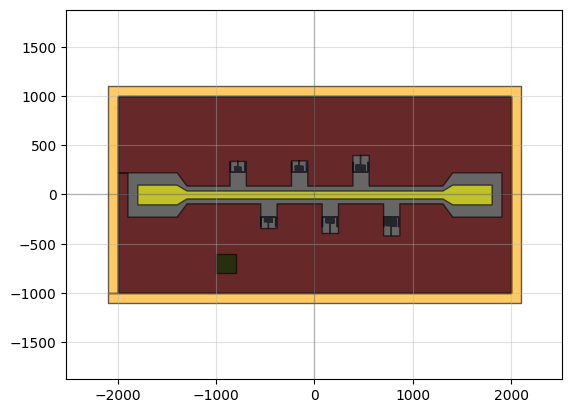

'C:\\Users\\miguelcarrerab\\OneDrive - Delft University of Technology\\Chatterjee Lab - Resonators\\Designs\\20260312-GeRes-NbTiN-12pHsq\\20260216-GeRes-NbTiN-12pHsq-v3-Cc136forAll.gds'

In [12]:

SeparationTlineResonator12 = [0]*7 + [5,0,10,0,10]
NumberOfResonators12 = 6

#Resonator parameters
CapacitorHorizontalLength12 = np.ones(NumberOfResonators12)*150
CapacitorVerticalLength12 = np.ones(NumberOfResonators12)*100
CapacitorWidth12 = np.ones(NumberOfResonators12)*5

NumberOfBends12 = np.ones(NumberOfResonators12, dtype=int)*[ 6, 6, 8, 9, 11, 14]
InductorVerticalLength12 = np.ones(NumberOfResonators12)*5
InductorHorizontalLength12 = np.ones(NumberOfResonators12)*[ 62,  78,  75,  82,  90,  100] 
InductorEndLength12 = np.ones(NumberOfResonators12)*( [55,55] + [50] + [90]*3)
InductorTotalLength12 = InductorVerticalLength12*(NumberOfBends12+4) + InductorEndLength12 +InductorHorizontalLength12*(NumberOfBends12+1)
InductorWidth12 = np.ones(NumberOfResonators12)*0.6
TaperWidth12 = np.ones(NumberOfResonators12)*20

SpacingC012 = np.ones(NumberOfResonators12)*5
# SpacingCc12 = np.ones(NumberOfResonators12)*np.sort(np.linspace(136,0,6))
SpacingCc12 = np.ones(NumberOfResonators12)*[136]
TaperLength12 = np.ones(NumberOfResonators12)*5
FinalSpacingBondpads12 = 100

freqs = []
# for i in range(NumberOfResonators12):
#     print(f'Resonator {i+1}')
#     freqs.append(resonance_freq_Schuster(InductorWidth12[i]*1e-6, CapacitorWidth12[i]*1e-6, (SeparationTlineResonator12[i] + FeedlineGap12 + SpacingCc12[i])*1e-6 , FeedlineWidth12*1e-6,
#                                             CapacitorVerticalLength12[i]*1e-6, SpacingC012[i]*1e-6,
#                                             InductorWidth12[i]*1e-6, InductorTotalLength12[i]*1e-6, Lk_24,
#                                         epsilon_r_Si, thickness_subs_Si)/1e9)                                        

print('Inductor total length is', InductorTotalLength12)
print('The frequencies are', freqs)
FeedlineWidth12 = 80
FeedlineLength12  = 2600
MetalAfterBondpad = 100
FeedlineGap12 = 50
FeedlineTaperLength12 =  100
BondpadWidth12 =  200
BondpadLength12 = 400
BondpadGap12 = BondpadWidth12*(FeedlineGap12/FeedlineWidth12)
ChipSize12 = [FeedlineLength12 + 2*BondpadLength12 + 2*FeedlineTaperLength12 + 2*FinalSpacingBondpads12 + 2*MetalAfterBondpad, 2000]

c, metal, chip12 = ChipResonatorsTline(ChipSize12, NumberOfResonators12, SeparationTlineResonator12,
                        FeedlineWidth12, FeedlineLength12, FeedlineGap12, 
                        FeedlineTaperLength12, BondpadWidth12, BondpadLength12, BondpadGap12,
                        CapacitorHorizontalLength12, CapacitorVerticalLength12, CapacitorWidth12,
                        NumberOfBends12, InductorVerticalLength12, InductorHorizontalLength12, InductorWidth12, InductorEndLength12,
                        TaperWidth12, TaperLength12, SpacingC012, SpacingCc12,
                        FinalSpacingBondpads12, MWO_simulation=False)

qp(chip12)

path = r"C:\Users\miguelcarrerab\OneDrive - Delft University of Technology\Chatterjee Lab - Resonators\Designs\20260312-GeRes-NbTiN-12pHsq"
if not os.path.exists(path):
    os.makedirs(path)  # Create the directory if it does not exist
chip12.write_gds(path + r"\20260216-GeRes-NbTiN-12pHsq-v3-Cc136forAll.gds")


Inductor total length is [ 539.  651.  785.  975. 1245. 1680.]
The frequencies are []
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


<class 'numpy.ndarray'>


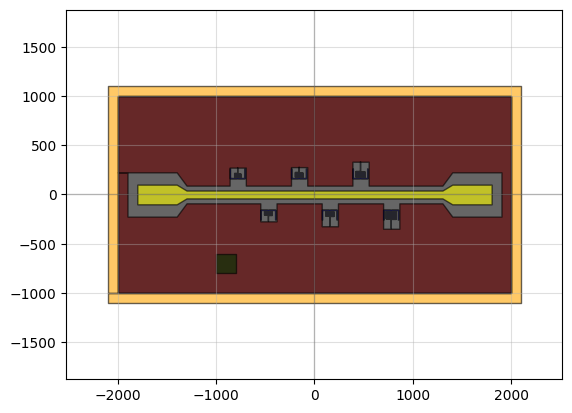

'C:\\Users\\miguelcarrerab\\OneDrive - Delft University of Technology\\Chatterjee Lab - Resonators\\Designs\\20260312-GeRes-NbTiN-12pHsq\\20260216-GeRes-NbTiN-12pHsq-v3-Cc68forAll.gds'

In [13]:

SeparationTlineResonator12 = [0]*7 + [5,0,10,0,10]
NumberOfResonators12 = 6

#Resonator parameters
CapacitorHorizontalLength12 = np.ones(NumberOfResonators12)*150
CapacitorVerticalLength12 = np.ones(NumberOfResonators12)*100
CapacitorWidth12 = np.ones(NumberOfResonators12)*5

NumberOfBends12 = np.ones(NumberOfResonators12, dtype=int)*[ 6, 6, 8, 9, 11, 14]
InductorVerticalLength12 = np.ones(NumberOfResonators12)*5
InductorHorizontalLength12 = np.ones(NumberOfResonators12)*[ 62,  78,  75,  82,  90,  100] 
InductorEndLength12 = np.ones(NumberOfResonators12)*( [55,55] + [50] + [90]*3)
InductorTotalLength12 = InductorVerticalLength12*(NumberOfBends12+4) + InductorEndLength12 +InductorHorizontalLength12*(NumberOfBends12+1)
InductorWidth12 = np.ones(NumberOfResonators12)*0.6
TaperWidth12 = np.ones(NumberOfResonators12)*20

SpacingC012 = np.ones(NumberOfResonators12)*5
# SpacingCc12 = np.ones(NumberOfResonators12)*np.sort(np.linspace(136,0,6))
SpacingCc12 = np.ones(NumberOfResonators12)*[136/2]
TaperLength12 = np.ones(NumberOfResonators12)*5
FinalSpacingBondpads12 = 100

freqs = []
# for i in range(NumberOfResonators12):
#     print(f'Resonator {i+1}')
#     freqs.append(resonance_freq_Schuster(InductorWidth12[i]*1e-6, CapacitorWidth12[i]*1e-6, (SeparationTlineResonator12[i] + FeedlineGap12 + SpacingCc12[i])*1e-6 , FeedlineWidth12*1e-6,
#                                             CapacitorVerticalLength12[i]*1e-6, SpacingC012[i]*1e-6,
#                                             InductorWidth12[i]*1e-6, InductorTotalLength12[i]*1e-6, Lk_24,
#                                         epsilon_r_Si, thickness_subs_Si)/1e9)                                        

print('Inductor total length is', InductorTotalLength12)
print('The frequencies are', freqs)
FeedlineWidth12 = 80
FeedlineLength12  = 2600
MetalAfterBondpad = 100
FeedlineGap12 = 50
FeedlineTaperLength12 =  100
BondpadWidth12 =  200
BondpadLength12 = 400
BondpadGap12 = BondpadWidth12*(FeedlineGap12/FeedlineWidth12)
ChipSize12 = [FeedlineLength12 + 2*BondpadLength12 + 2*FeedlineTaperLength12 + 2*FinalSpacingBondpads12 + 2*MetalAfterBondpad, 2000]

c, metal, chip12 = ChipResonatorsTline(ChipSize12, NumberOfResonators12, SeparationTlineResonator12,
                        FeedlineWidth12, FeedlineLength12, FeedlineGap12, 
                        FeedlineTaperLength12, BondpadWidth12, BondpadLength12, BondpadGap12,
                        CapacitorHorizontalLength12, CapacitorVerticalLength12, CapacitorWidth12,
                        NumberOfBends12, InductorVerticalLength12, InductorHorizontalLength12, InductorWidth12, InductorEndLength12,
                        TaperWidth12, TaperLength12, SpacingC012, SpacingCc12,
                        FinalSpacingBondpads12, MWO_simulation=False)

qp(chip12)

path = r"C:\Users\miguelcarrerab\OneDrive - Delft University of Technology\Chatterjee Lab - Resonators\Designs\20260312-GeRes-NbTiN-12pHsq"
if not os.path.exists(path):
    os.makedirs(path)  # Create the directory if it does not exist
chip12.write_gds(path + r"\20260216-GeRes-NbTiN-12pHsq-v3-Cc68forAll.gds")


In [14]:
BondpadGap12

125.0